In [145]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("C:/Users/Vasagam/Downloads/bmi(d).csv")
df.head()

,Age,Gender,Height,Weight,Physical Activity per day (hrs),Hours of Sleep per day,Bmi,BmiClass
0,61,Male,185.0,109.30,1,8,31.94,Obese Class 1
1,60,Female,171.0,79.02,0,7,27.02,Overweight
2,60,Male,155.0,74.70,3,3,31.09,Obese Class 1
3,60,Female,146.0,35.90,3,7,16.84,Underweight
4,60,Male,158.0,97.10,0,10,38.90,Obese Class 2


In [147]:
df.describe()

,Age,Height,Weight,Physical Activity per day (hrs),Hours of Sleep per day,Bmi
count,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000
mean,39.726852,171.382870,82.388843,2.537037,6.740741,27.771481
std,12.927145,8.636329,30.178191,1.653332,2.322270,9.496252
min,15.000000,146.000000,35.900000,0.000000,3.000000,16.180000
25%,29.000000,167.000000,63.500000,1.000000,5.000000,22.242500
50%,40.500000,172.000000,73.455000,3.000000,7.000000,25.235000
75%,50.250000,176.250000,95.175000,4.000000,9.000000,29.157500
max,61.000000,193.000000,182.700000,5.000000,10.000000,66.300000


In [149]:
numeric_cols = ['Age', 'Height', 'Weight', 'Bmi']

ranges = df[numeric_cols].max() - df[numeric_cols].min()
ranges

Age        46.00
Height     47.00
Weight    146.80
Bmi        50.12
dtype: float64

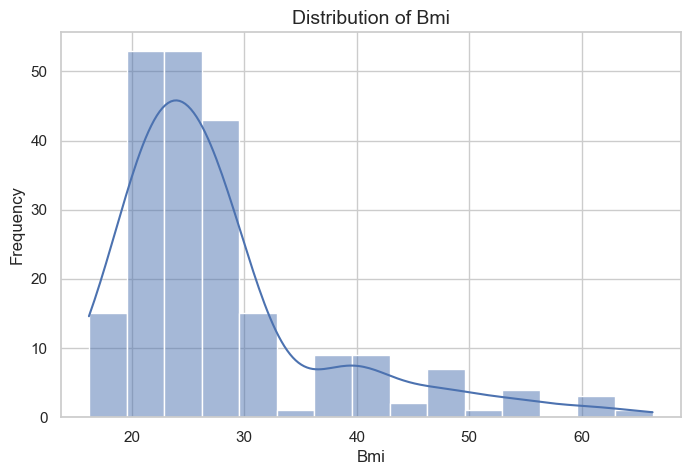

In [151]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

for col in ['Bmi']:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], kde=True, bins=15)
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


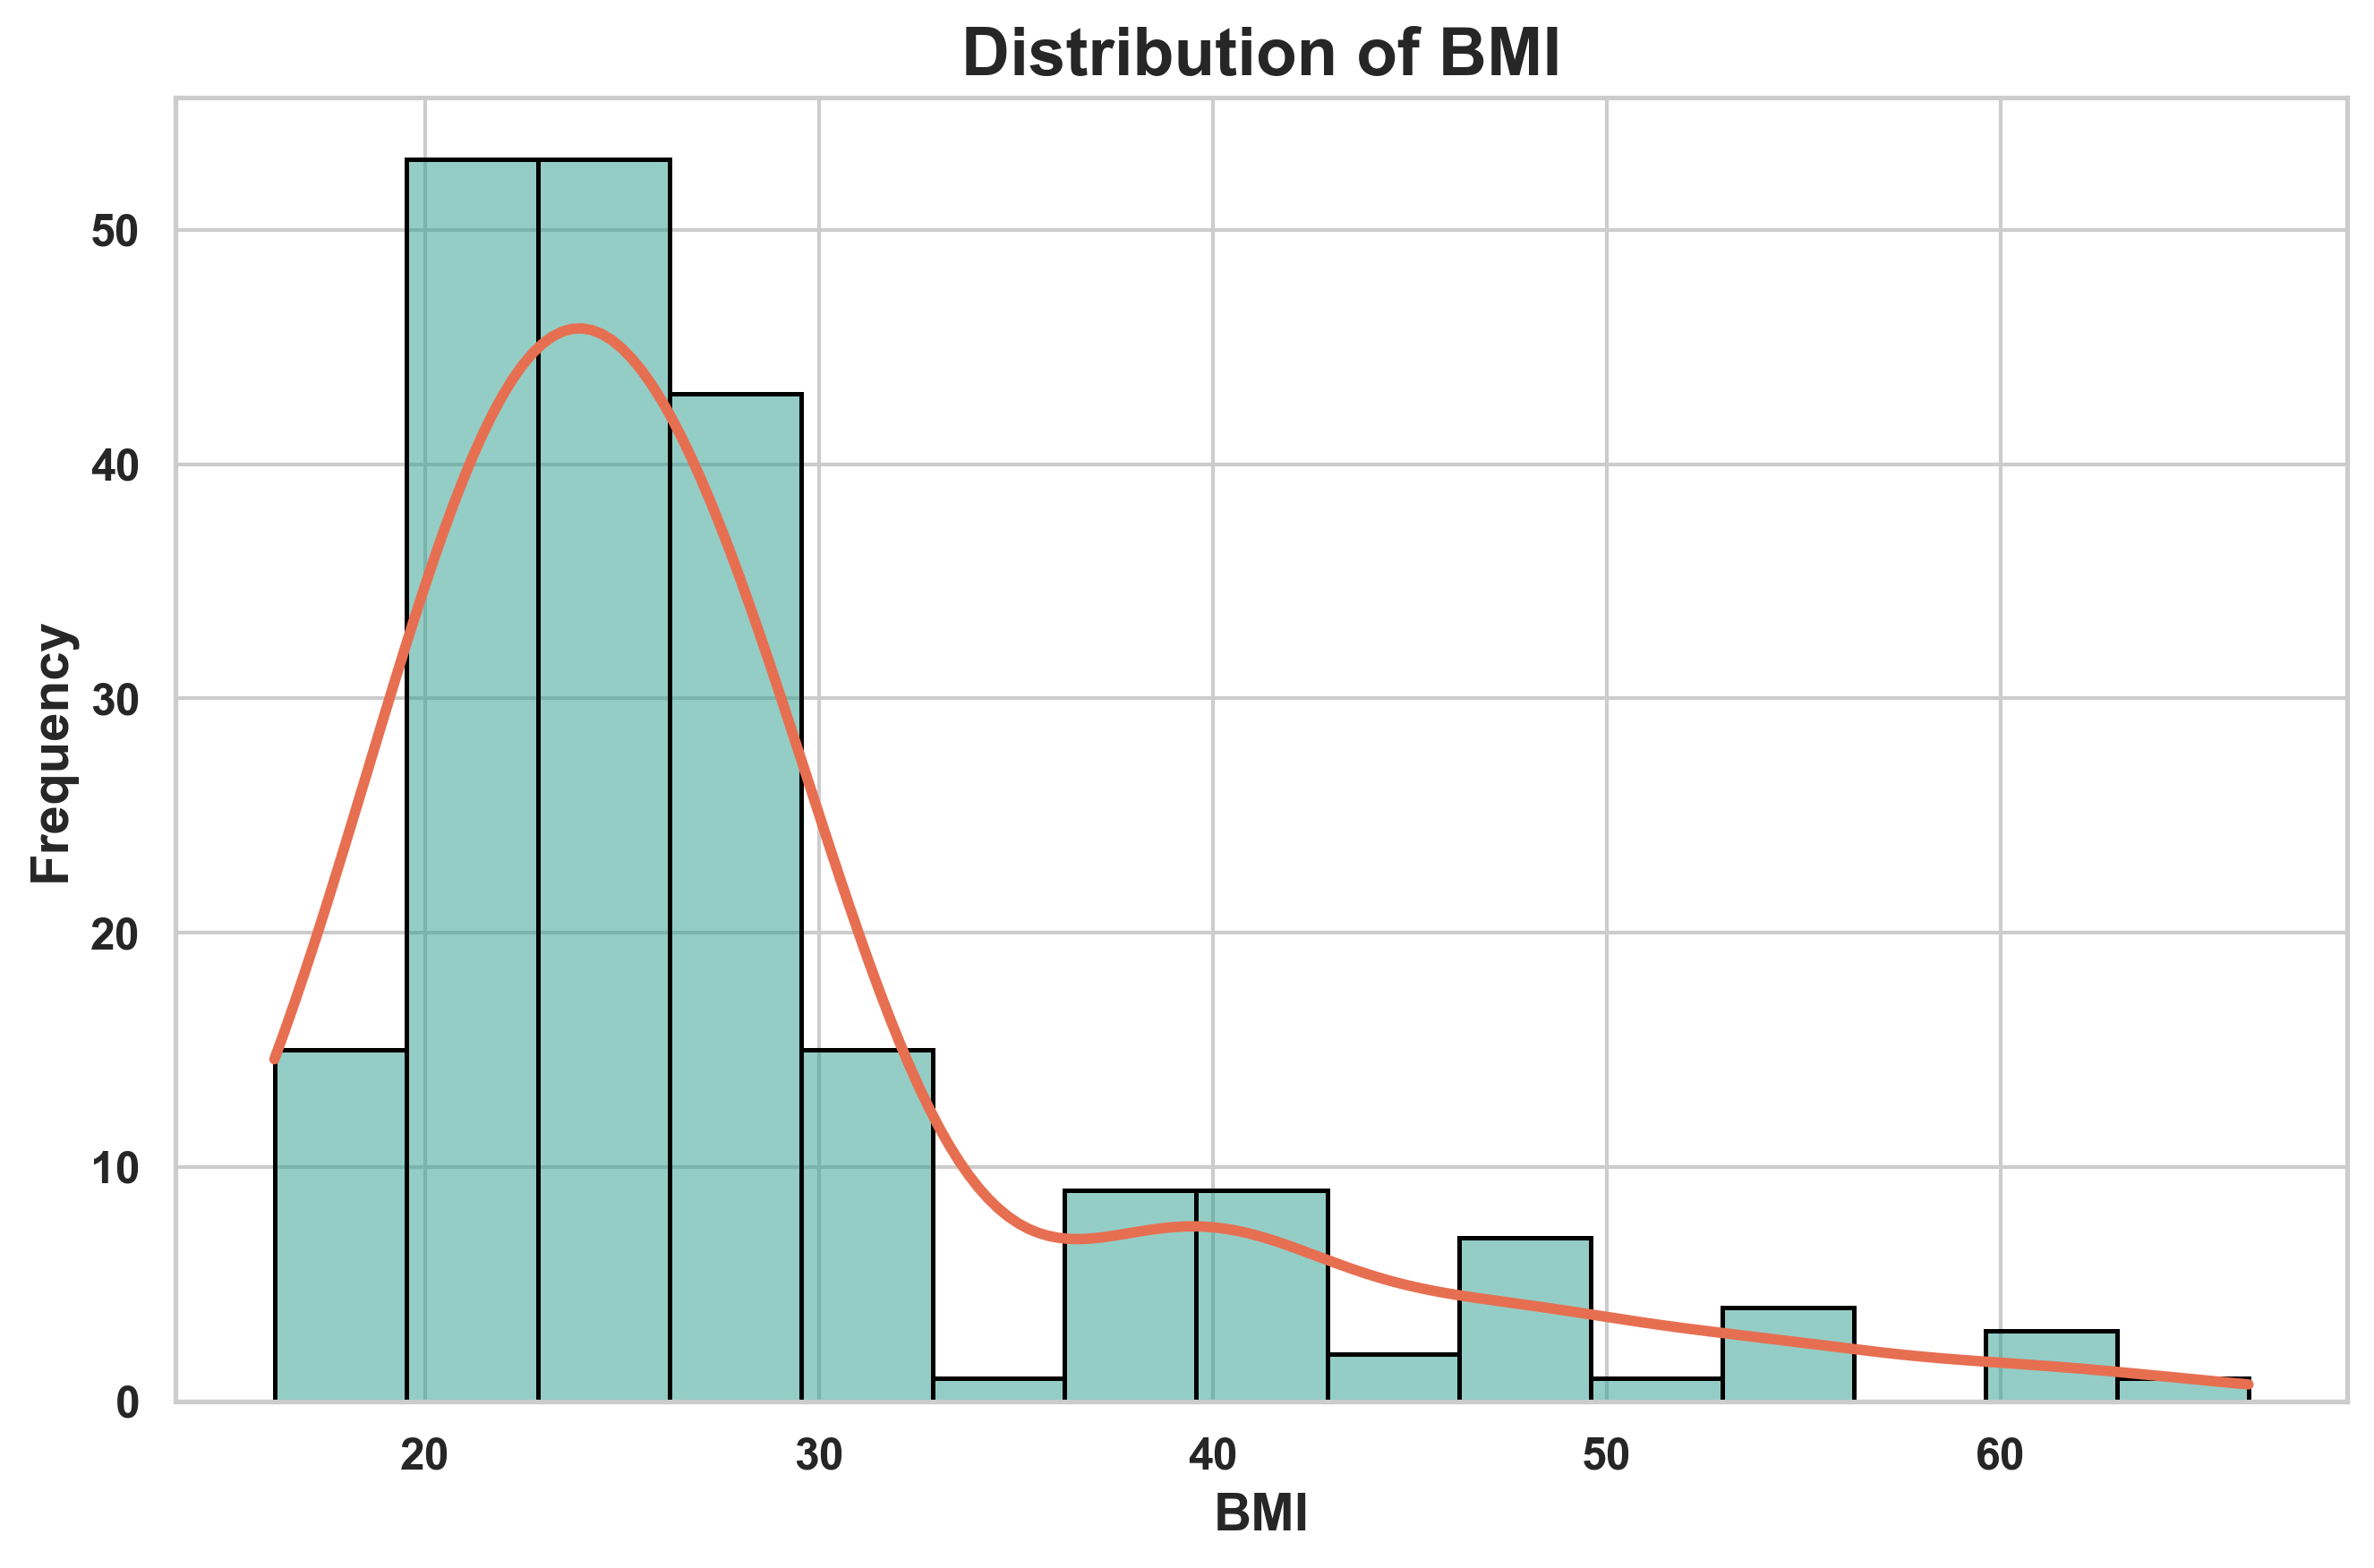

In [153]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(9,6), dpi=300)  # Higher dpi = sharper image

ax = sns.histplot(
    df['Bmi'],
    kde=True,
    bins=15,
    color='#2A9D8F',        # soft teal bin color
    edgecolor='black',      # outline bars for clarity
    linewidth=1.2
)

# ---- Formatting Text ----
plt.title("Distribution of BMI", fontsize=18, fontweight='bold')
plt.xlabel("BMI", fontsize=14, fontweight='bold')
plt.ylabel("Frequency", fontsize=14, fontweight='bold')

# Bold tick labels
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# KDE line style adjustment (optional)
for line in ax.lines:
    line.set_linewidth(2.8)
    line.set_color('#E76F51')   # contrasting red curve

plt.tight_layout()
plt.show()


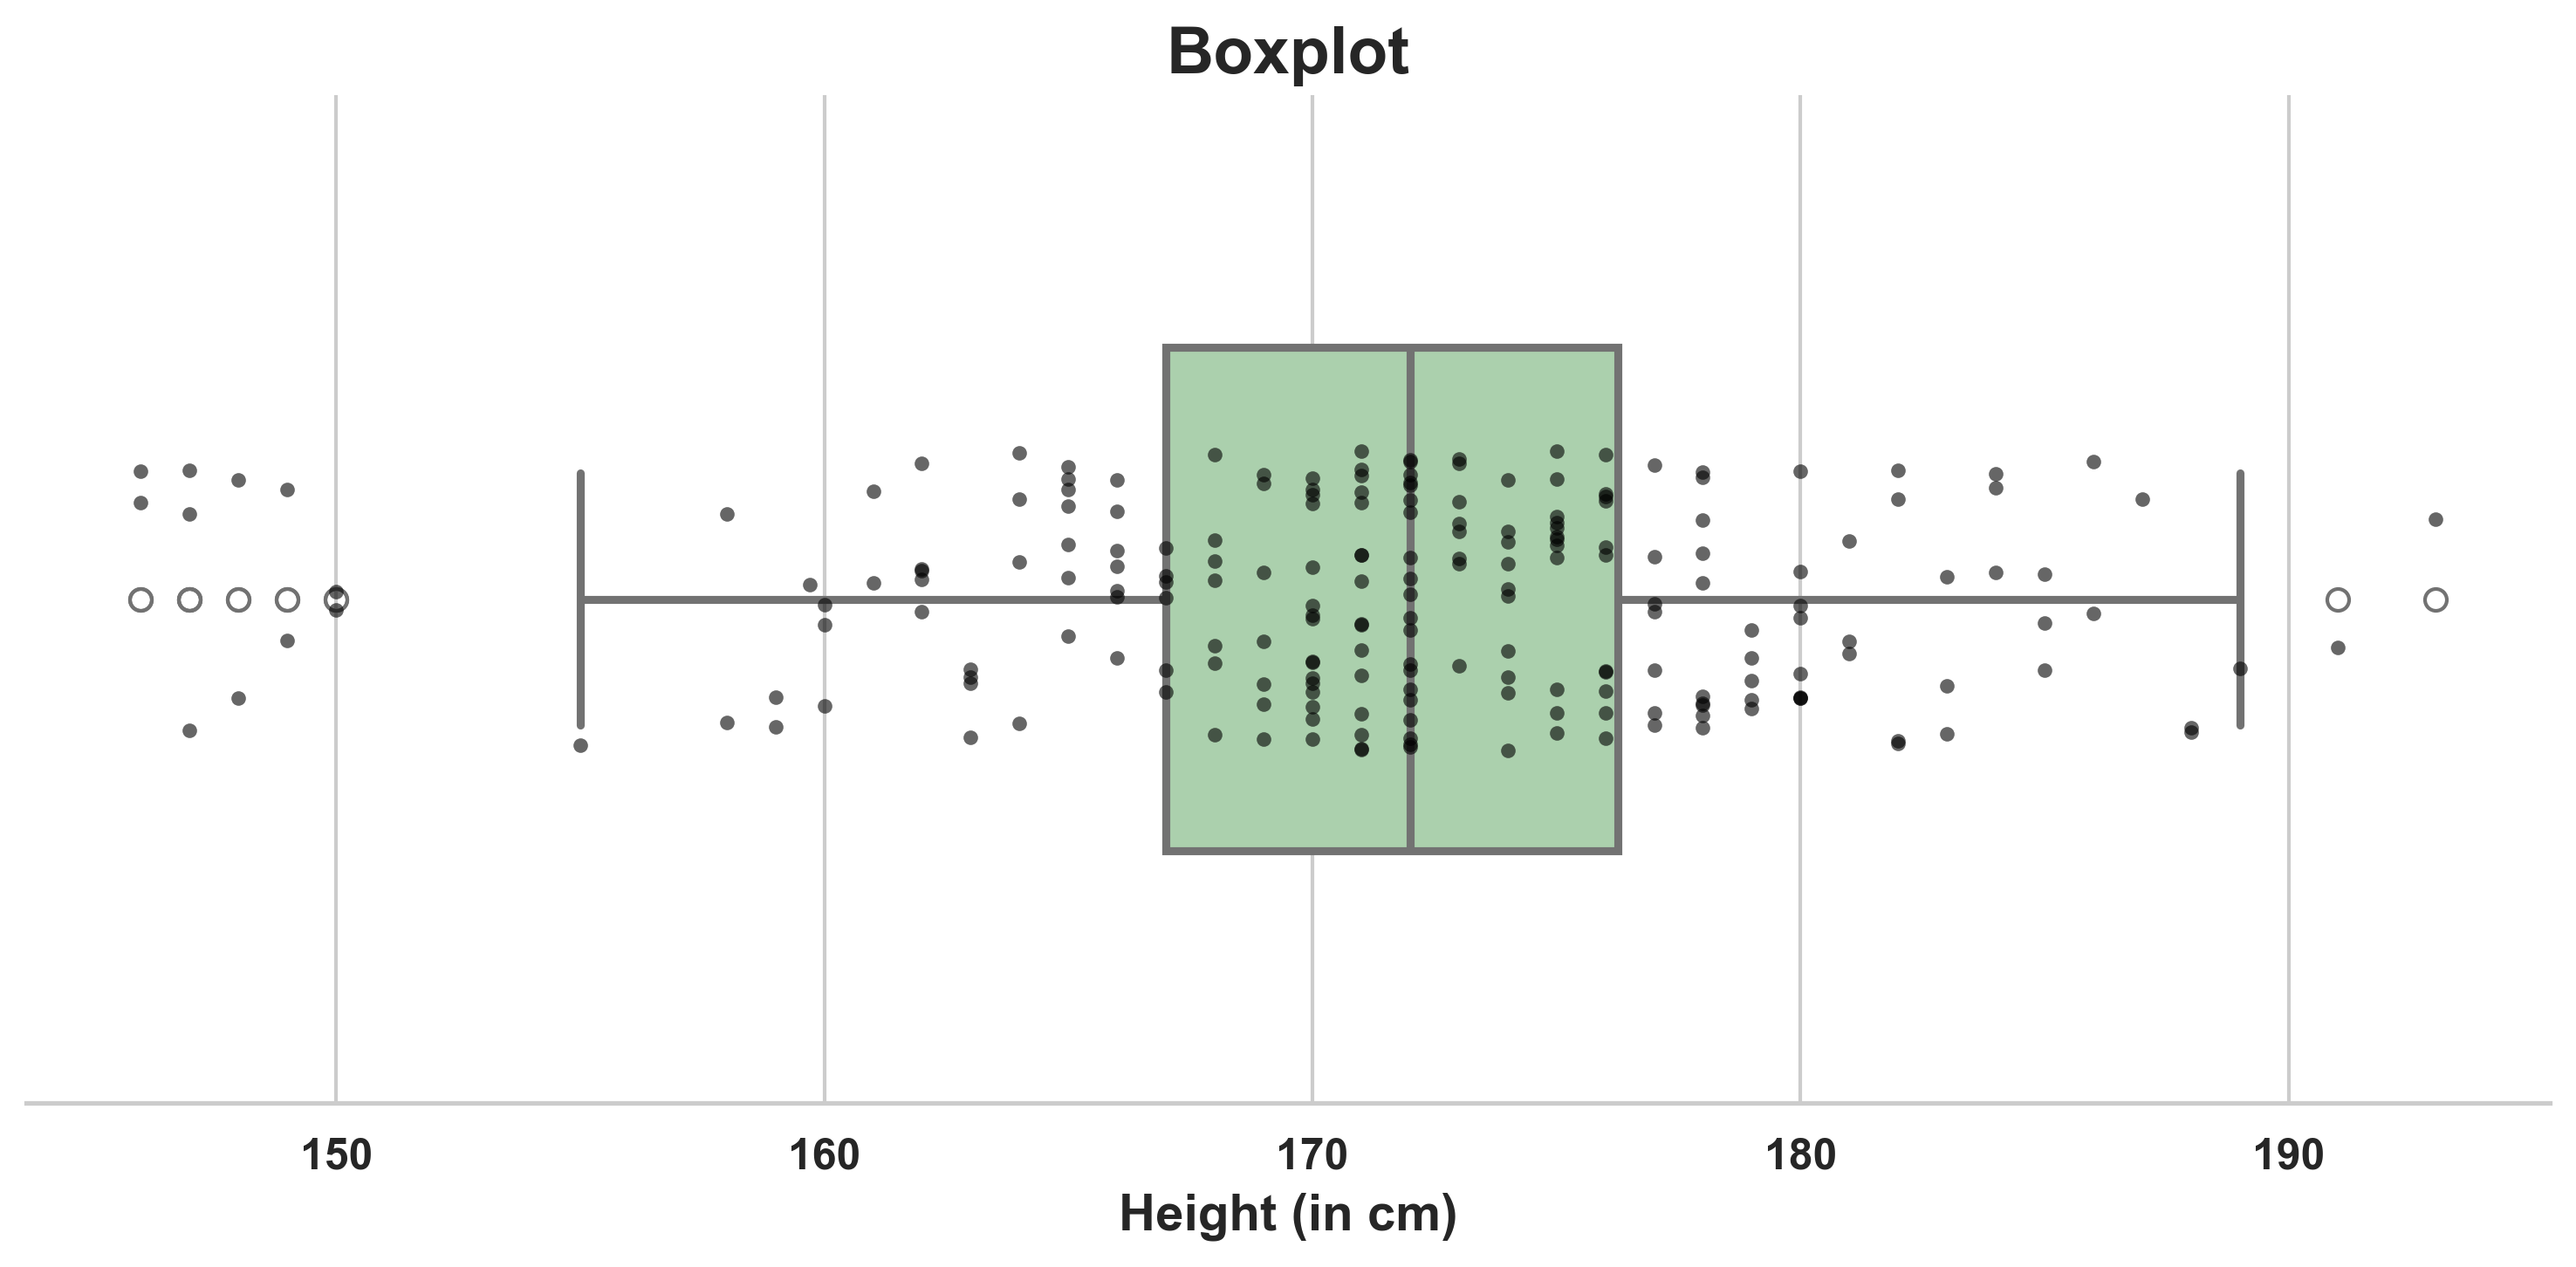

In [161]:
plt.figure(figsize=(10,5), dpi=300)

sns.boxplot(x=df['Height'], color="#A5D6A7", width=0.5, linewidth=2.2)
sns.stripplot(x=df['Height'], color='black', size=4, jitter=0.15, alpha=0.6)

plt.title("Boxplot", fontsize=18, fontweight='bold')
plt.xlabel("Height (in cm)", fontsize=14, fontweight='bold')

plt.xticks(fontsize=12, fontweight='bold')
sns.despine(left=True)
plt.tight_layout()
plt.show()

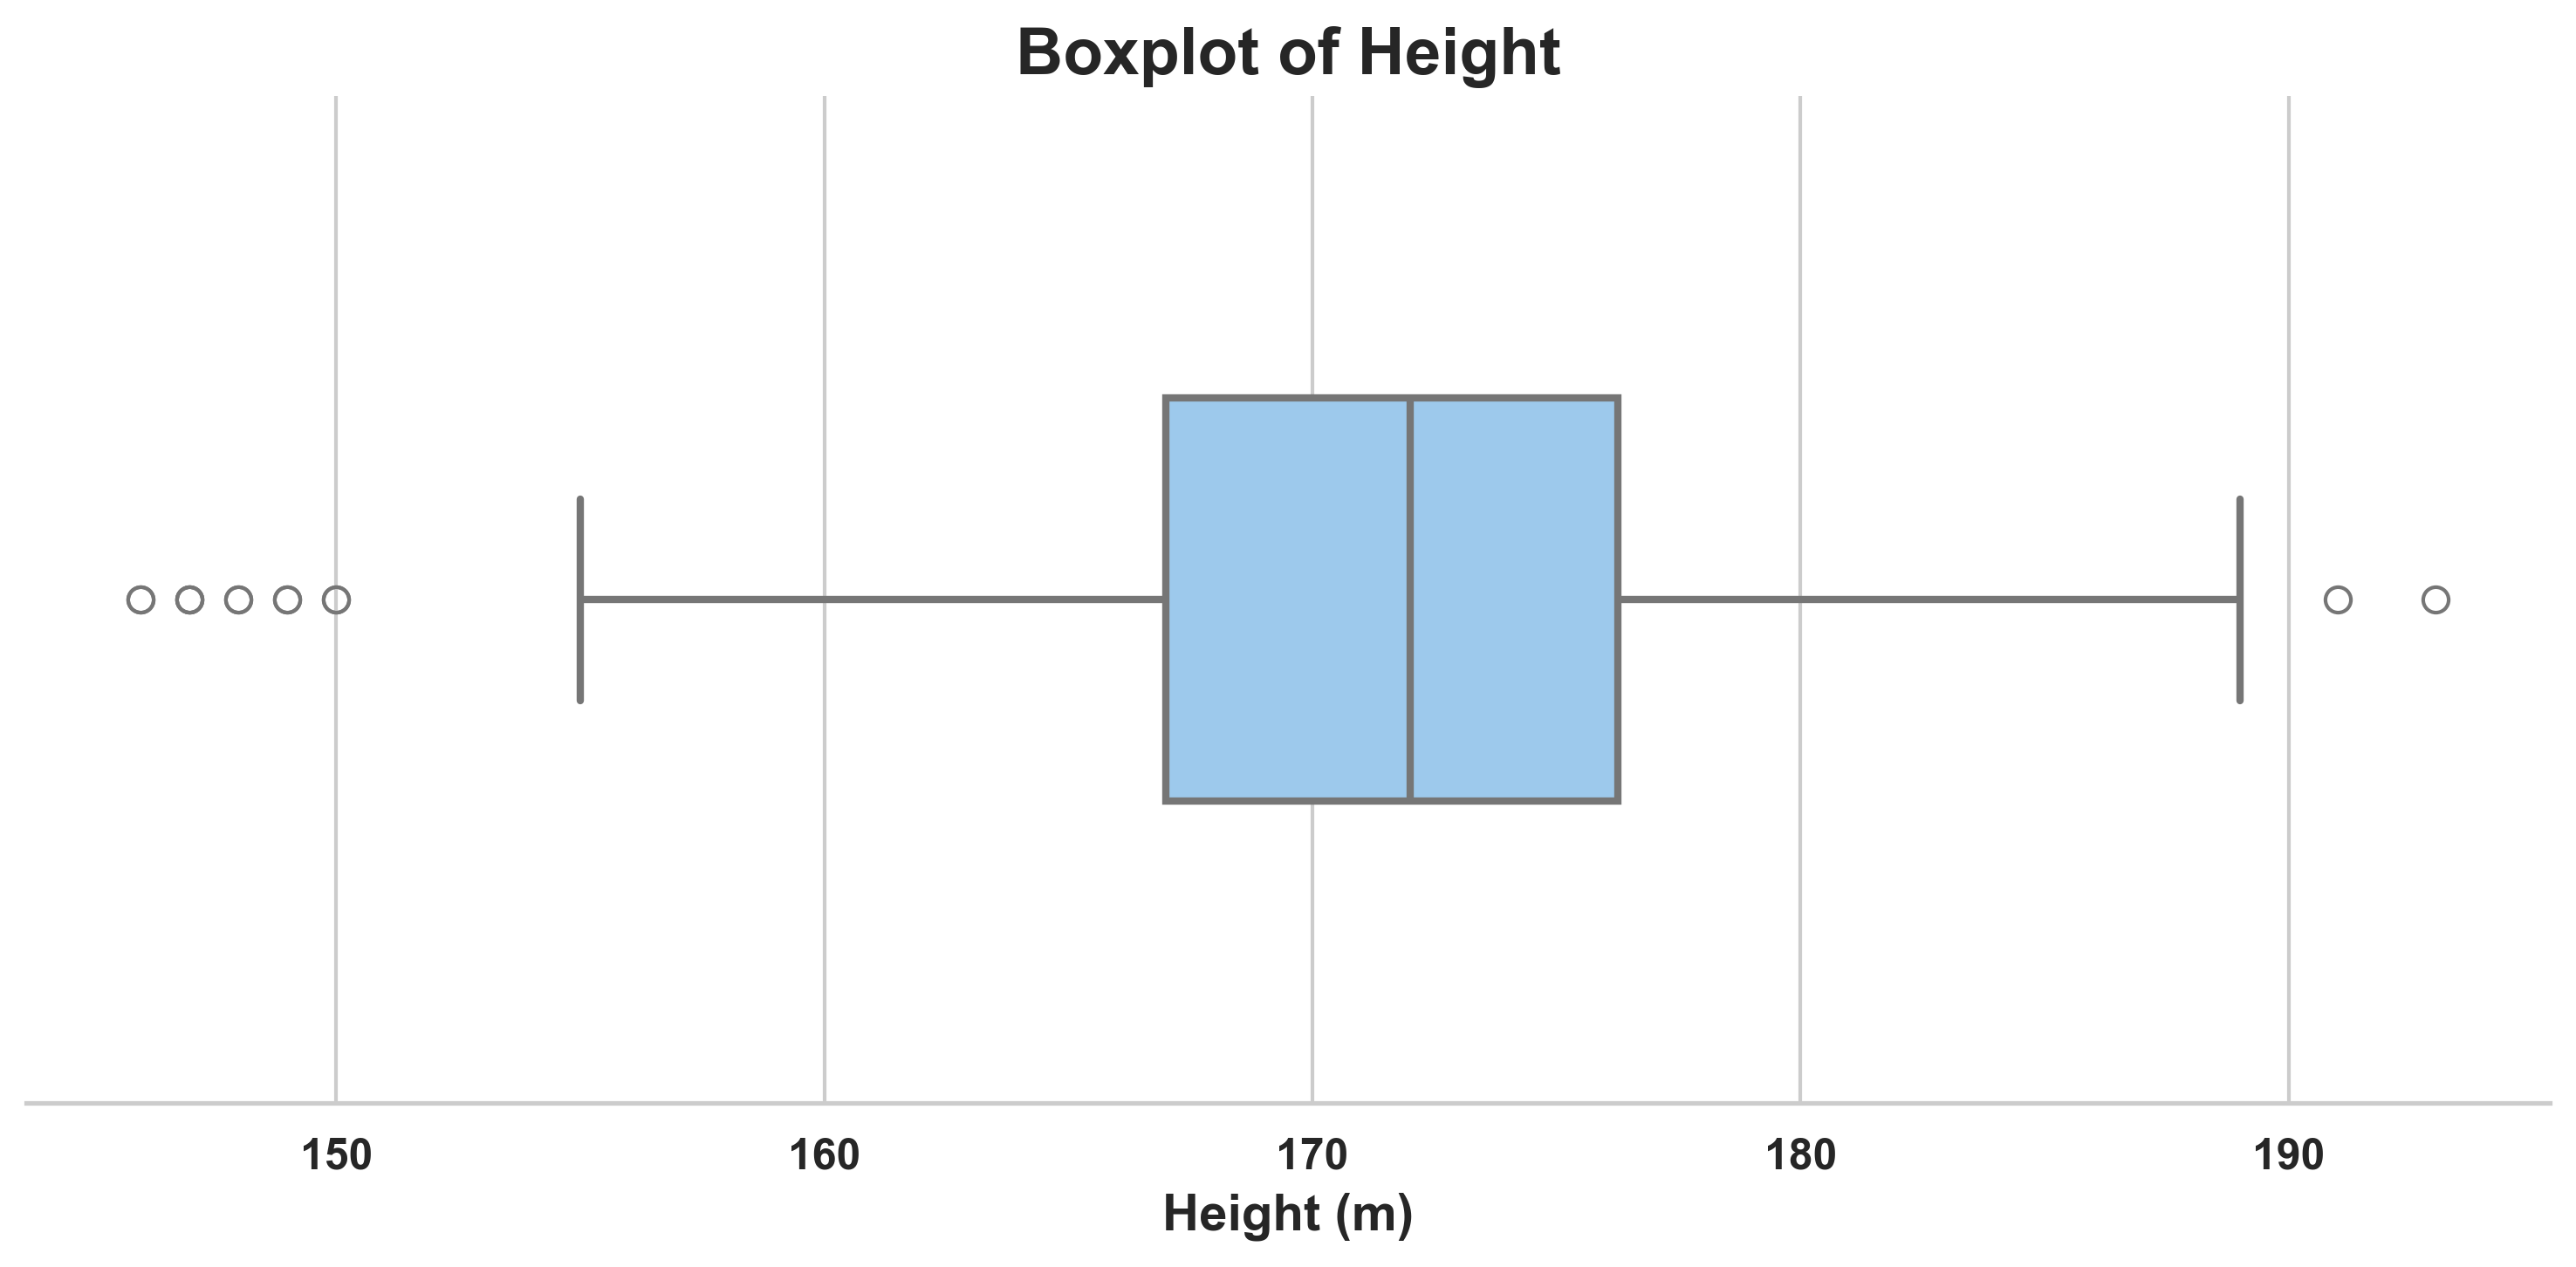

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5), dpi=300)

sns.boxplot(
    x=df['Height'], 
    width=0.4,
    color="#90CAF9",     # soft blue
    fliersize=7,         # bigger outliers
    linewidth=2.0        # bold border
)

plt.title("Boxplot of Height", fontsize=18, fontweight='bold')
plt.xlabel("Height (m)", fontsize=14, fontweight='bold')

plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

sns.despine(left=True)   # remove spine for a cleaner look
plt.tight_layout()
plt.show()


In [165]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['Gender_encoded'] = encoder.fit_transform(df['Gender'])
df['BmiClass_encoded'] = encoder.fit_transform(df['BmiClass'])


In [167]:
encoder.classes_

array(['Normal Weight', 'Obese Class 1', 'Obese Class 2', 'Obese Class 3',
       'Overweight', 'Underweight'], dtype=object)

In [169]:
X = df[['Age', 'Height', 'Weight', 'Gender_encoded']]

# With dark data
#X = df[['Age', 'Height', 'Weight', 'Gender_encoded', 'Physical Activity per day (hrs)','Hours of Sleep per day']]
y = df['BmiClass_encoded']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [171]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

In [173]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9545454545454546

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      0.50      0.67         2
           2       0.50      1.00      0.67         1
           3       1.00      0.75      0.86         4
           4       0.94      1.00      0.97        15
           5       1.00      1.00      1.00         1

    accuracy                           0.95        44
   macro avg       0.91      0.88      0.86        44
weighted avg       0.97      0.95      0.95        44



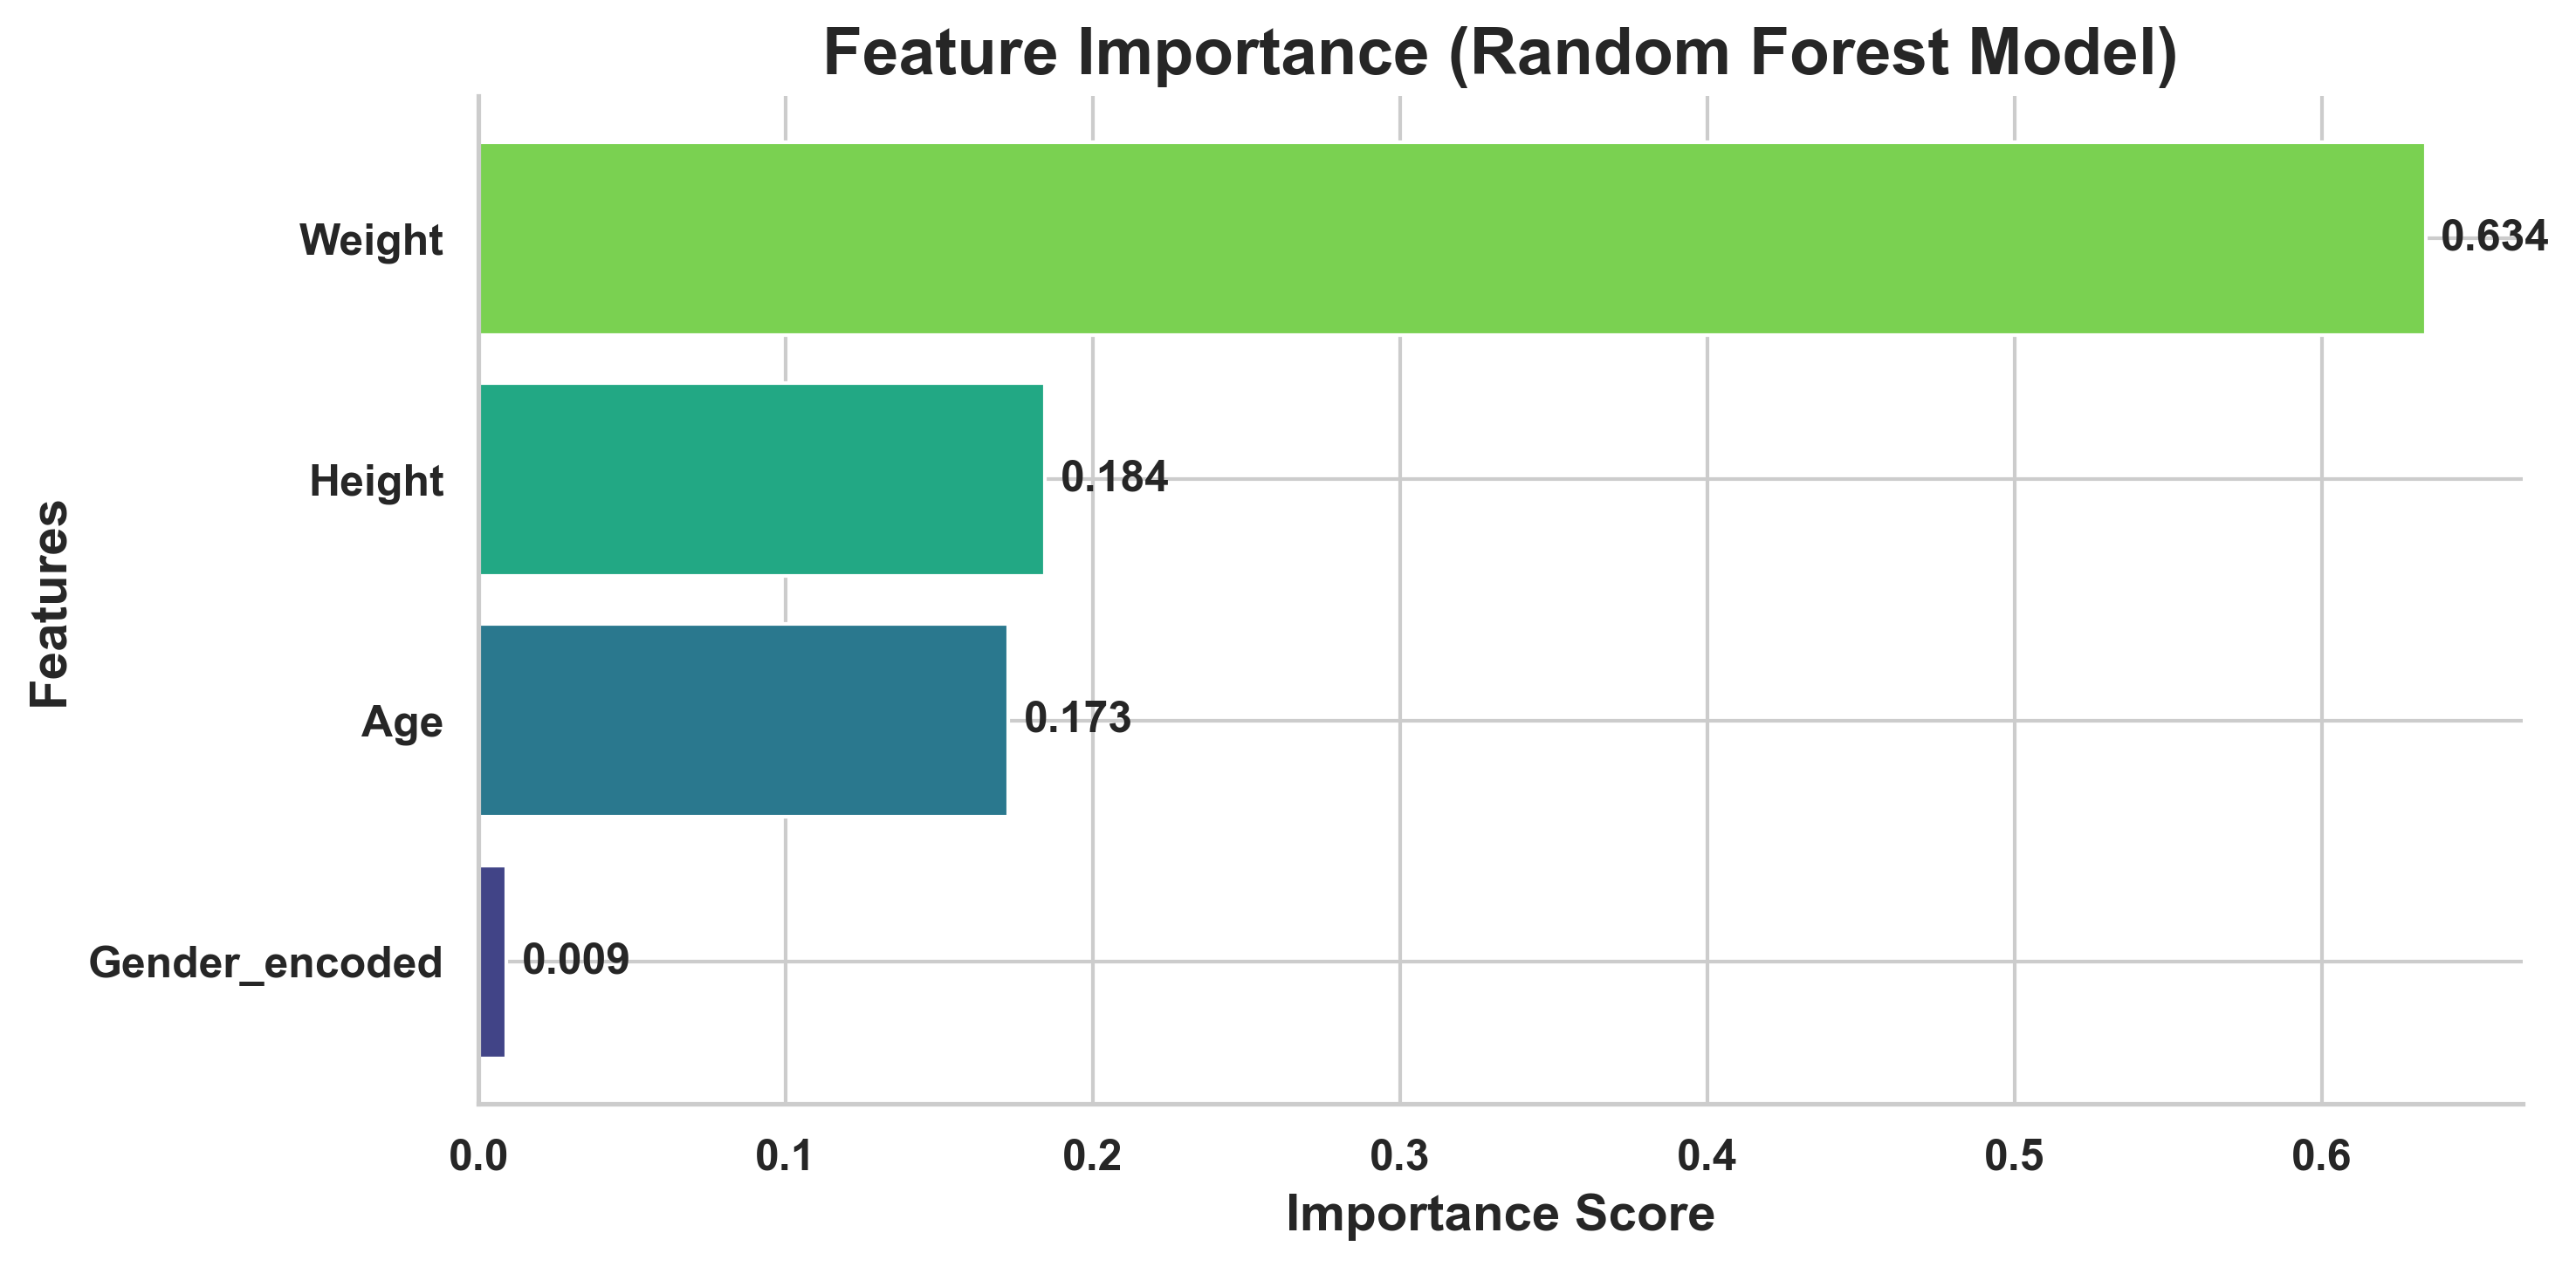

In [175]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create the series again in sorted order
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(10,5), dpi=300)

# Choose a nice color palette
colors = sns.color_palette("viridis", len(feature_importance))

# Plot
bars = plt.barh(feature_importance.index, feature_importance.values, color=colors)

# Add numerical labels to bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f"{width:.3f}", fontsize=12, fontweight="bold",
             va='center')

# Titles and labels formatting
plt.title("Feature Importance (Random Forest Model)", fontsize=18, fontweight='bold')
plt.xlabel("Importance Score", fontsize=14, fontweight='bold')
plt.ylabel("Features", fontsize=14, fontweight='bold')

# Format ticks
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

sns.despine(left=False)
plt.tight_layout()
plt.show()


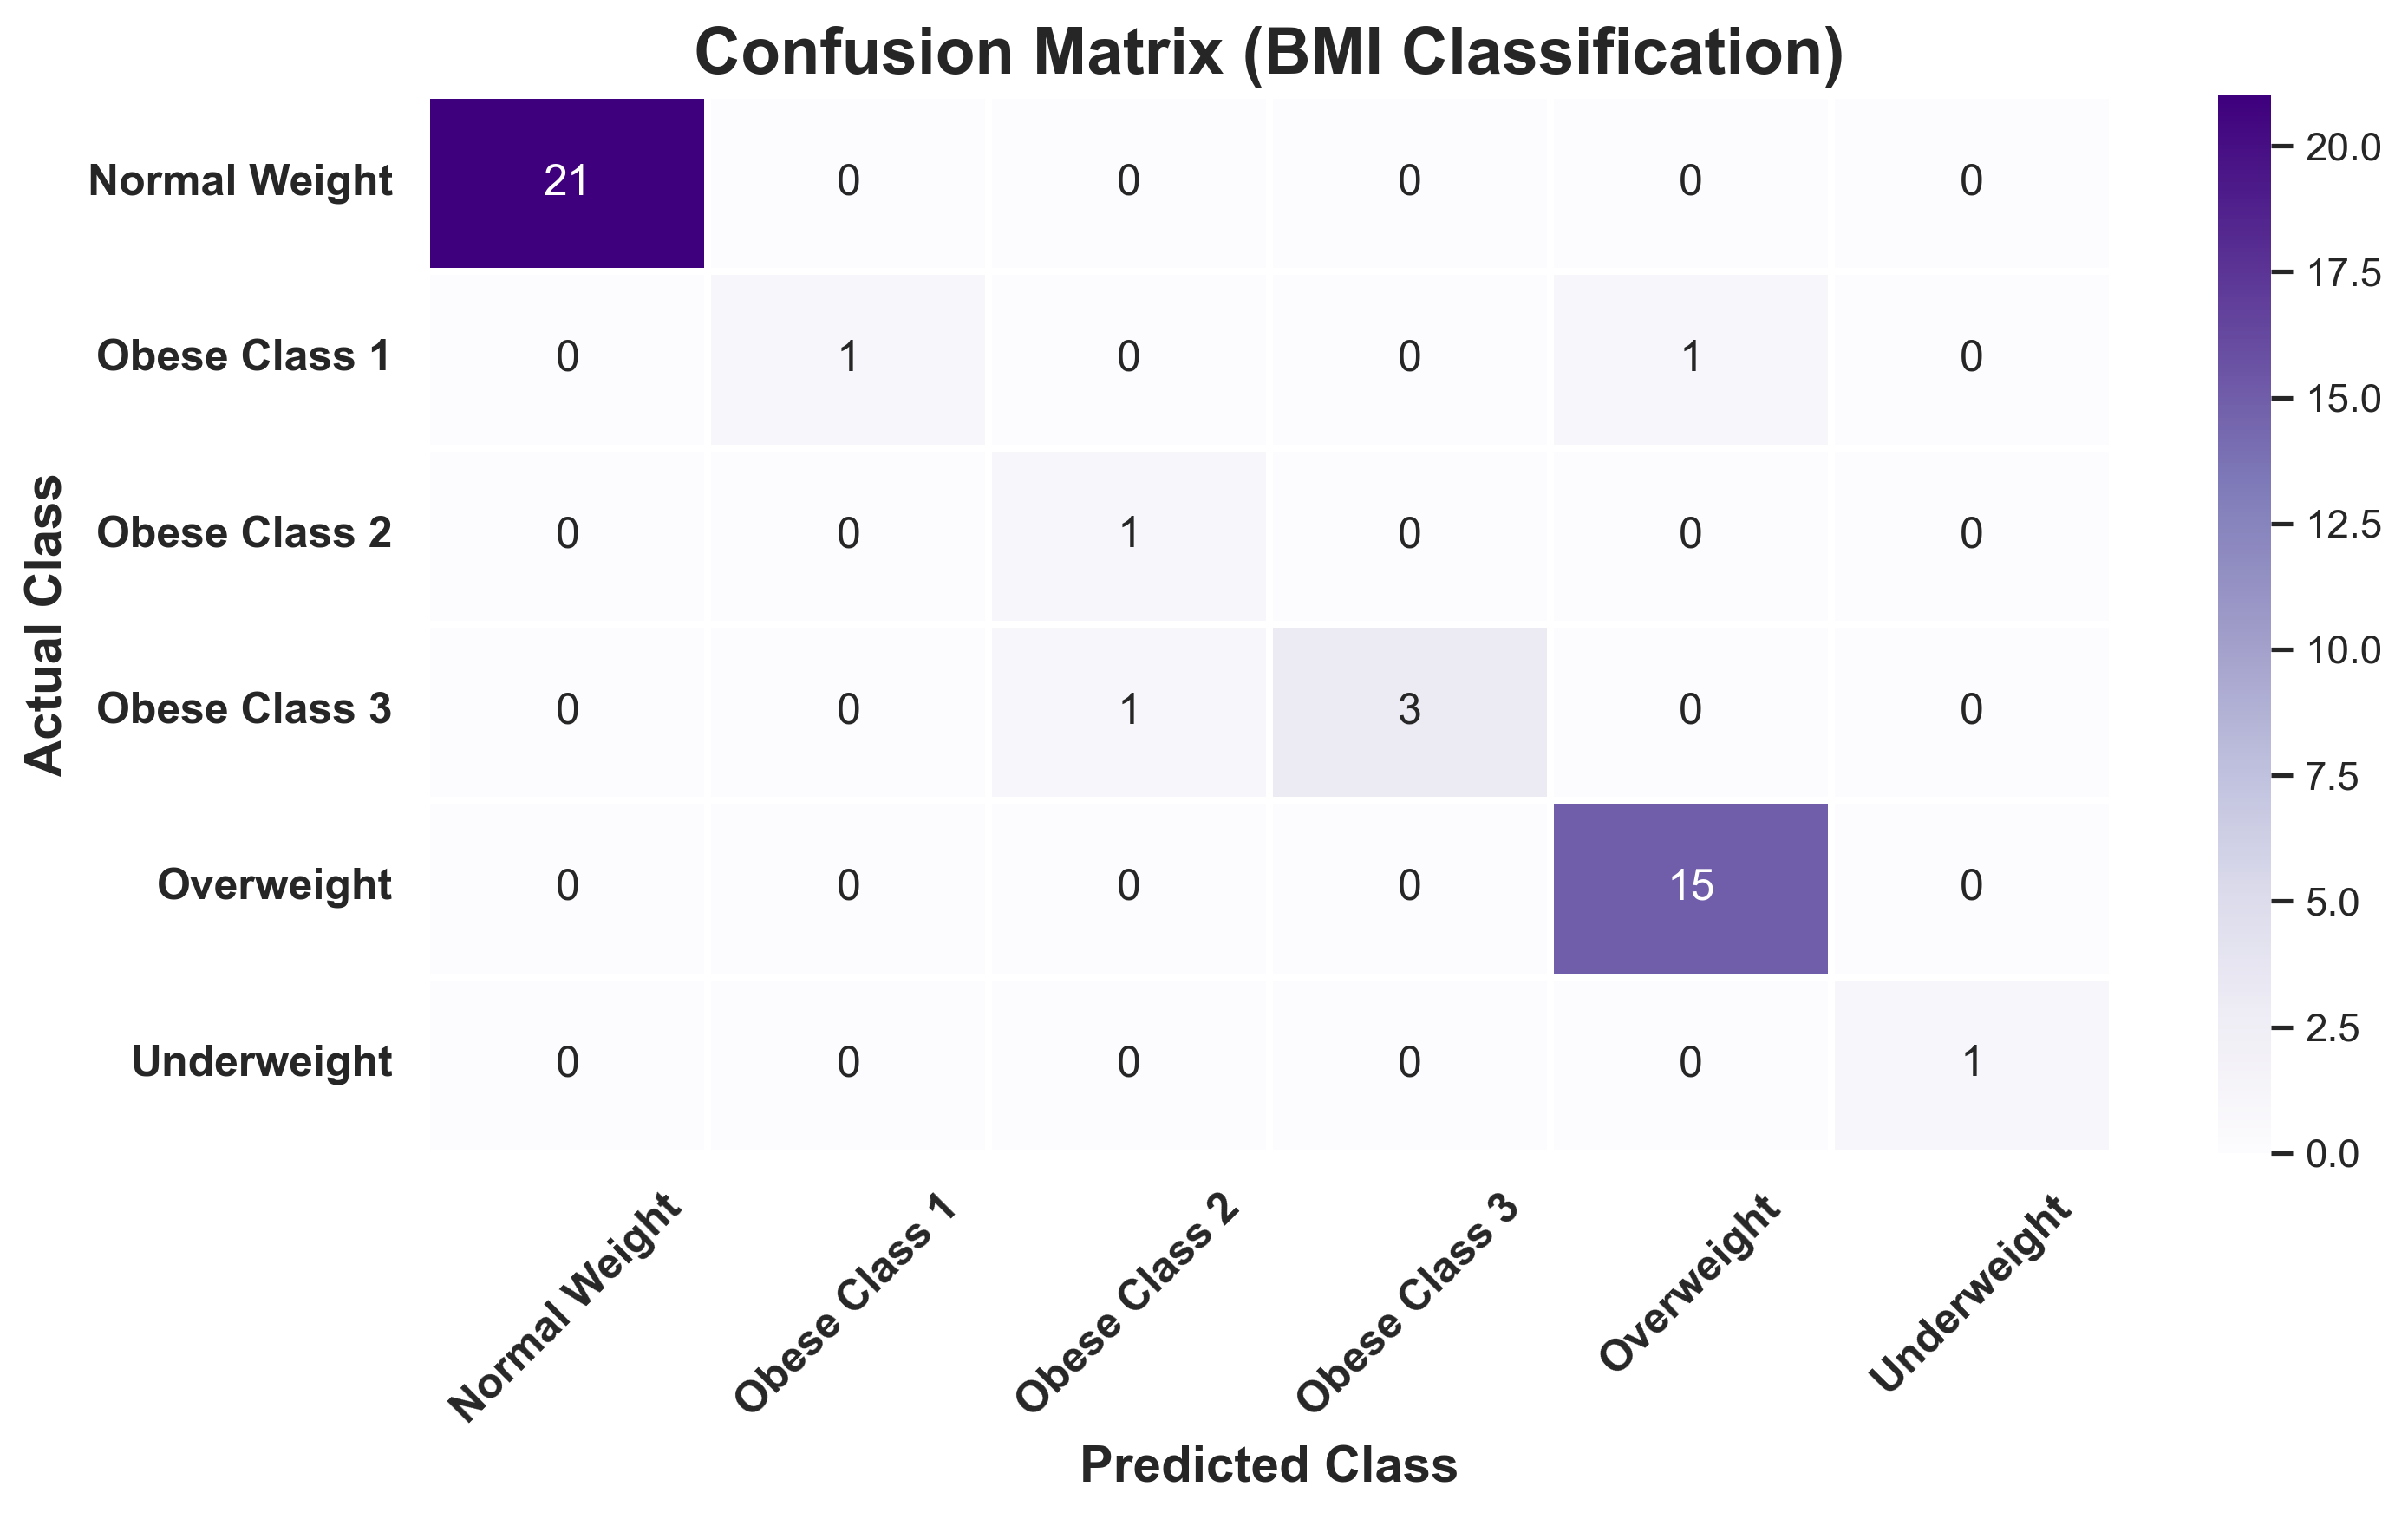

In [177]:
labels = encoder.classes_   # uses your earlier LabelEncoder mapping

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,6), dpi=300)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', linewidths=1.5,
            xticklabels=labels, yticklabels=labels)

plt.title("Confusion Matrix (BMI Classification)", fontsize=18, fontweight='bold')
plt.xlabel("Predicted Class", fontsize=14, fontweight='bold')
plt.ylabel("Actual Class", fontsize=14, fontweight='bold')

plt.xticks(rotation=45, fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()